In [1]:
# IMPORTING LIBRARIES
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing

In [2]:
# LOADING DATASET, DEFINE TARGET VAR
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target
print(df.head())

# SPLITTING OF DATA INTO TRAINING AND TESTING DATASET
from sklearn.model_selection import train_test_split


X = df.drop(columns=['Price'])   # all columns except price
y = df['Price']                  # value to be predicted

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [3]:
# TRAIN LINEAR REGRESSION MODEL
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)   

# PREDICTION
y_pred = model.predict(X_test)

# Evaluation
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean squared error is:", mse)
print("R2 score is:", r2)


Mean squared error is: 0.5558915986952442
R2 score is: 0.575787706032451


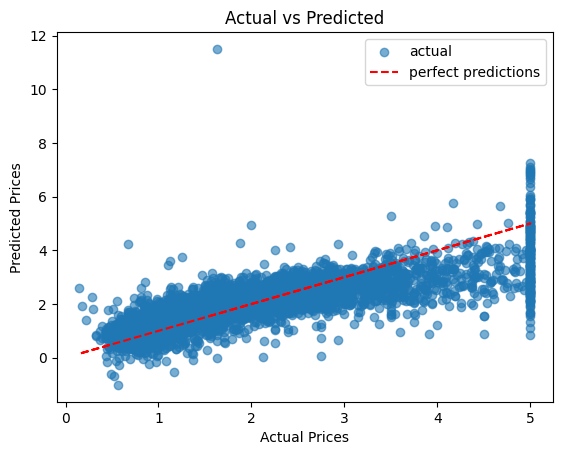

In [8]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.6,label='actual')
plt.plot(y_test, y_test, color='red', linestyle='--',label='perfect predictions')  # Line for perfect predictions
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

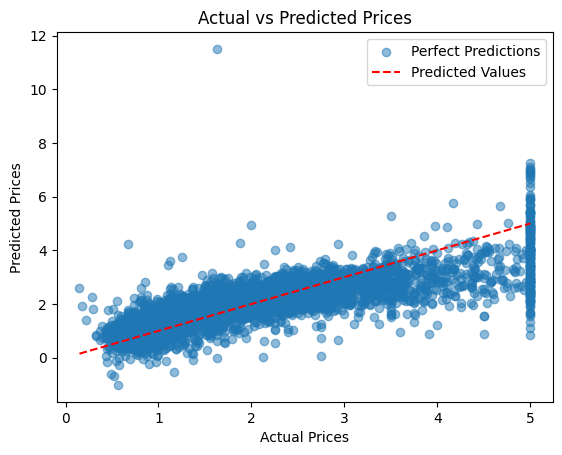

In [10]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.5)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.legend(["Perfect Predictions", "Predicted Values"])
plt.show()


## Residual Plot

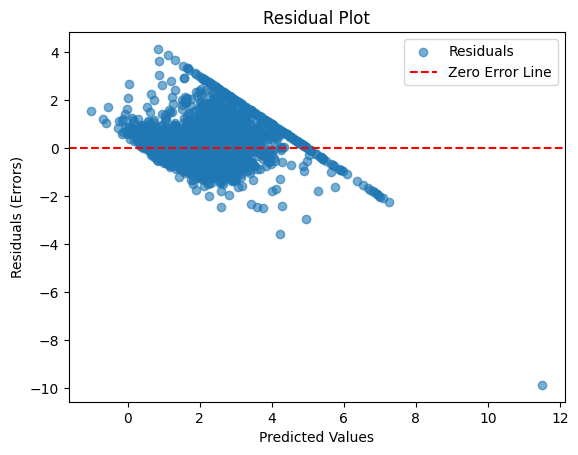

In [12]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.6)

# It is a function in Matplotlib used to draw a horizontal line across the plot
#It draws a straight line at a fixed y-value
plt.axhline(y=0, color='r', linestyle='--') 

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Errors)")
plt.title("Residual Plot")
plt.legend(["Residuals", "Zero Error Line"])
plt.show()

## Histogram of errors


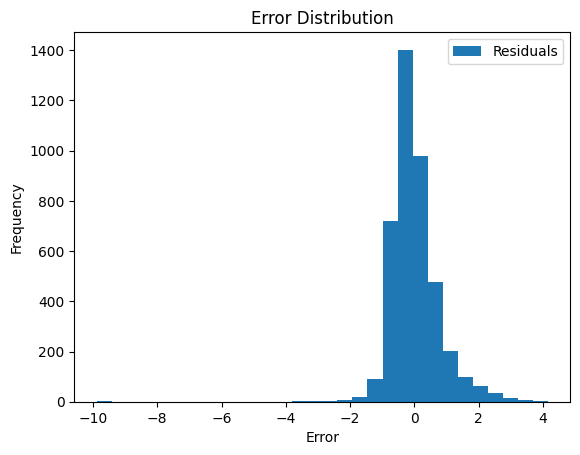

In [13]:
plt.hist(y_test - y_pred, bins=30)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.legend(["Residuals"])
plt.show()

## Feature Importance

In [14]:
import pandas as pd

coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coeff_df.sort_values(by="Coefficient", ascending=False))

      Feature  Coefficient
3   AveBedrms     0.783145
0      MedInc     0.448675
1    HouseAge     0.009724
4  Population    -0.000002
5    AveOccup    -0.003526
2    AveRooms    -0.123323
6    Latitude    -0.419792
7   Longitude    -0.433708


## Single Feature vs Target

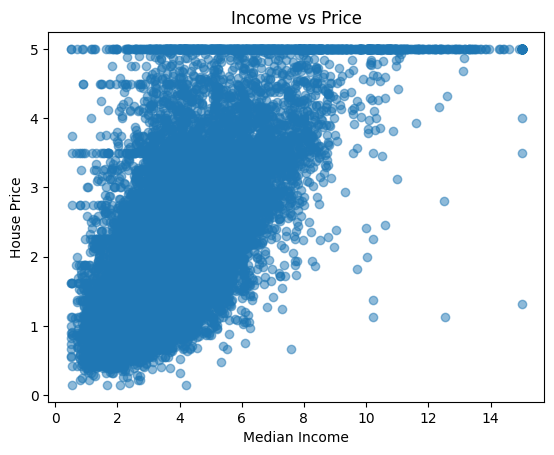

In [ ]:


import matplotlib.pyplot as plt

plt.scatter(df['MedInc'], df['Price'], alpha=0.5)  #alpha controls transperancy in a plot

plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Income vs Price")
plt.legend(["Data Points"])
plt.show()